# GTEx Tissue Feature Importance Analysis (SHAP-based)

This notebook identifies the most important Latent Variables (LVs) from CLAMPfull_BP for each GTEx tissue.

Key steps:
1. Load GTEx LV data and tissue metadata
2. Check LV correlations (multicollinearity analysis)
3. Train Random Forest classifiers with nested cross-validation
4. Extract SHAP (SHapley Additive exPlanations) feature importance

💡 **Environment:** `clamp-analyses`

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict
from pyprojroot.here import here
import shap

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]

import csv
import seaborn as sns

from itertools import groupby

np.random.seed(42)

# Settings

In [2]:
# Configuration
GLOBAL_SEED = 42
N_TOP_FEATURES = 10  # Number of top features to report per tissue
CORRELATION_THRESHOLD = 0.8  # Threshold for flagging highly correlated LVs

# Random Forest hyperparameter grid
PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

# Output

In [ ]:
# Output paths
OUTPUT_DIR = here('output/gtex_feature_importance')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

# Load Data

In [4]:
# Load .rds files from CLAMP with different priors
gtex_GO_BP_CLAMP_rds = readRDS(str(here('output/gtex/gtex_GO_Biological_Process_2025_CLAMP.rds')))
gtex_GTEx_Tissues_CLAMP_rds = readRDS(str(here('output/gtex/gtex_GTEx_Tissues_V8_2023_CLAMP.rds')))


# Helper function to extract B matrix and convert to pandas DataFrame
def extract_B_matrix(rds_obj):
    """Extract B matrix from RDS object and convert to transposed DataFrame."""
    B_matrix = rds_obj.rx2("B")
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

# Extract B matrices
gtex_GO_BP_CLAMP = extract_B_matrix(gtex_GO_BP_CLAMP_rds)
gtex_GTEx_Tissues_CLAMP = extract_B_matrix(gtex_GTEx_Tissues_CLAMP_rds)

lv_data = gtex_GO_BP_CLAMP
lv_data.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,0.006759,0.173195,0.114383,0.065135,0.146581,0.061427,-0.091098,0.000505,0.009718,0.020368,...,0.106458,0.137352,-0.030704,0.031164,0.025875,-0.000259,0.009356,0.239786,0.051815,0.052207
LV2,-0.140148,-0.274049,-0.152115,-0.103755,-0.163344,-0.212786,-0.111394,-0.109608,-0.241989,-0.159123,...,-0.168385,-0.054046,-0.120964,-0.203427,-0.172900,-0.038693,-0.213974,-0.159670,-0.308787,-0.261958
LV3,-0.232106,-0.004709,-0.113917,-0.191952,0.122528,-0.230804,-0.193743,0.131371,-0.185984,0.009386,...,0.403192,0.036904,-0.079862,0.149330,0.153025,-0.127416,0.184733,0.015280,0.036017,-0.138703
LV4,0.881004,-0.117299,0.109259,0.106998,0.219328,0.185064,0.233521,-0.106990,0.257177,0.332270,...,0.128451,0.053828,0.100443,0.145727,-0.018876,0.281622,-0.304837,-0.076291,-0.159131,0.255077
LV5,-0.130820,-0.006781,-0.045980,0.032497,0.048327,0.057472,-0.195523,0.466854,-0.078420,0.011491,...,0.037300,-0.054704,-0.026536,-0.005050,-0.030537,-0.207290,0.444314,-0.084185,-0.034158,-0.068817


In [70]:
def extract_summary_matrix(rds_obj):
    """Extract summary matrix from RDS object and convert to DataFrame."""
    summary_matrix = rds_obj.rx2("summary")  # or whatever the name is
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        summary_values = ro.conversion.rpy2py(summary_matrix)
    
    df = pd.DataFrame(
        data=summary_values,
        index=summary_matrix.rownames if summary_matrix.rownames else None,
        columns=summary_matrix.colnames if summary_matrix.colnames else None,
    )
    return df

# Extract summary matrices
gtex_GO_BP_summary = extract_summary_matrix(gtex_GO_BP_CLAMP_rds)
gtex_GTEx_Tissues_summary = extract_summary_matrix(gtex_GTEx_Tissues_CLAMP_rds)

print(gtex_GO_BP_summary.shape)
gtex_GO_BP_summary.head()

(3212, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
GO_Biological_Process_202538,C4-dicarboxylate Transport (GO:0015740),LV1,0.864817,0.022703,0.168026,2,21482
GO_Biological_Process_202551,DNA Biosynthetic Process (GO:0071897),LV1,0.293548,0.917271,0.945118,3,21482
GO_Biological_Process_2025271,Actin Filament Polymerization (GO:0030041),LV1,0.378712,0.826605,0.945118,4,21482
GO_Biological_Process_2025479,Biogenic Amine Metabolic Process (GO:0006576),LV1,0.502653,0.494220,0.807443,2,21482
GO_Biological_Process_2025882,Dehydroascorbic Acid Transport (GO:0070837),LV1,0.458547,0.589956,0.840559,2,21482


In [6]:
gtex_GTEx_Tissues_summary.head()

,pathway,LV,AUC,p_value,FDR,npos,nneg
GTEx_Tissues_V8_202349,Colon - Transverse Male 60-69 Up,LV1,0.712687,0.050105,0.068832,4,21390
GTEx_Tissues_V8_202364,Cells - Cultured Fibroblasts Female 60-69 Up,LV1,0.551479,0.193018,0.234161,19,21390
GTEx_Tissues_V8_202395,Cells - Cultured Fibroblasts Male 50-59 Up,LV1,0.630538,0.013973,0.021199,19,21390
GTEx_Tissues_V8_2023176,Cells - Cultured Fibroblasts Male 30-39 Up,LV1,0.648694,0.007403,0.011751,18,21390
GTEx_Tissues_V8_2023229,Cells - Cultured Fibroblasts Male 20-29 Up,LV1,0.642074,0.009942,0.015449,18,21390


In [7]:
# Load GTEx metadata

path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,   
    engine='python',
    comment=None,            
    keep_default_na=False,
    on_bad_lines='warn'     
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [8]:
# Transpose to get samples as rows, LVs as columns
lv_matrix = lv_data.T

# Filter metadata to only include samples in LV matrix
meta_filtered = gtex_meta[gtex_meta['SAMPID'].isin(lv_matrix.index)].copy()
meta_filtered = meta_filtered.set_index('SAMPID')
meta_filtered = meta_filtered.loc[lv_matrix.index]  # Align order

# Use SMTS (tissue type) or SMTSD (detailed tissue) as target
tissue_labels = meta_filtered['SMTS']  # or 'SMTSD' for detailed tissue types

print(f"Number of samples: {len(lv_matrix)}")
print(f"Number of LVs: {lv_matrix.shape[1]}")
print(f"Number of unique tissues: {tissue_labels.nunique()}")
print(f"\nTissue distribution:")
print(tissue_labels.value_counts().head())

Number of samples: 17382
Number of LVs: 412
Number of unique tissues: 30

Tissue distribution:
SMTS
Brain             2642
Skin              1809
Esophagus         1445
Blood Vessel      1335
Adipose Tissue    1204
Name: count, dtype: int64


In [ ]:
tissue_labels.head()

In [10]:
lv_matrix.head()

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV403,LV404,LV405,LV406,LV407,LV408,LV409,LV410,LV411,LV412
GTEX-1117F-0226-SM-5GZZ7,0.006759,-0.140148,-0.232106,0.881004,-0.130820,0.025952,-0.061344,0.005071,-0.135607,-0.048286,...,0.074395,-0.024974,0.028596,-0.007853,0.030052,0.078004,0.052269,-0.000719,0.094574,-0.025361
GTEX-1117F-0426-SM-5EGHI,0.173195,-0.274049,-0.004709,-0.117299,-0.006781,-0.077349,0.062145,0.020984,-0.070707,-0.007448,...,-0.004699,-0.084580,-0.039862,-0.009377,0.037887,0.028406,-0.085347,-0.178703,0.038800,-0.160363
GTEX-1117F-0526-SM-5EGHJ,0.114383,-0.152115,-0.113917,0.109259,-0.045980,-0.023866,-0.259630,0.001824,-0.052376,-0.210150,...,0.091213,-0.030581,-0.024232,-0.018810,0.094997,0.083616,0.067893,-0.035854,0.161798,-0.102202
GTEX-1117F-0626-SM-5N9CS,0.065135,-0.103755,-0.191952,0.106998,0.032497,-0.117515,-0.089866,0.046372,0.221156,0.008865,...,-0.070271,-0.030287,0.027885,0.033204,-0.004464,-0.018260,0.049004,-0.003260,0.043489,0.178370
GTEX-1117F-0726-SM-5GIEN,0.146581,-0.163344,0.122528,0.219328,0.048327,-0.078419,-0.196034,0.022642,0.011061,-0.073363,...,-0.105980,-0.048887,0.038217,0.015039,0.002456,0.001090,0.006501,0.004214,-0.222580,0.057349


In [86]:
phenoplier_path = here('data/gtex/phenoplier/gtex-gls-summary-phenomexcan.tsv.gz')

phenoplier = pd.read_csv(
    phenoplier_path,
    sep="\t",
    compression="gzip",
    low_memory=False
)

print(phenoplier.shape)
print(phenoplier.columns.tolist())

(1668188, 5)
['phenotype', 'phenotype_desc', 'lv', 'pvalue', 'fdr']


# LV Correlation Analysis

Before running feature importance, we need to check for multicollinearity among LVs.
Highly correlated features can affect SHAP importance interpretation.
Pearson correlation

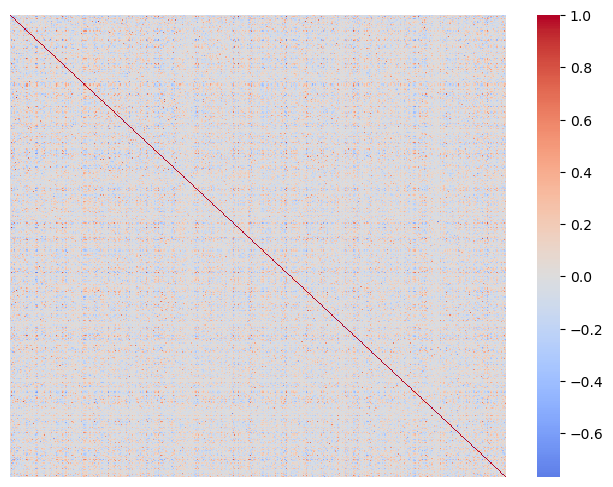

Number of highly correlated pairs (|r| > 0.9): 1


In [12]:
# Correlation matrix
corr_matrix = lv_matrix.corr()

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            xticklabels=False, yticklabels=False)
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print(f"Number of highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")

LVs independent

# Feature Importance Analysis (SHAP)

For each tissue, we train a Random Forest classifier (tissue vs. rest) and extract SHAP importance scores.

The analysis uses nested cross-validation:
- Outer CV: For unbiased performance estimation
- Inner CV: For hyperparameter tuning

In [ ]:
global_seed = 42

# Parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

tissues = tissue_labels.unique()

accuracy_list = []
shap_results_list = []
cumulative_importance_list = []

top5_lvs_by_tissue = {}

(OUTPUT_DIR / "per_tissue").mkdir(parents=True, exist_ok=True)

for i, tissue in enumerate(tissues):
    print(f"[{i+1}/{len(tissues)}] {tissue}")
    
    # Create binary target: 1 if sample belongs to this tissue, 0 otherwise
    y_binary = (tissue_labels == tissue).astype(int)
    
    # Class distribution info
    n_pos = y_binary.sum()
    n_neg = (1 - y_binary).sum()
    imbalance_ratio = n_neg / n_pos if n_pos > 0 else float('inf')
    
    # n_splits = 5 --> 80% training 20% testing
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
    outer_test_scores = []
    best_params_list = []
    
    for outer_fold, (dev_idx, test_idx) in enumerate(outer_cv.split(lv_matrix, y_binary)):
        lv_data_dev = lv_matrix.iloc[dev_idx]
        y_dev = y_binary.iloc[dev_idx]
        lv_data_test = lv_matrix.iloc[test_idx]
        y_test = y_binary.iloc[test_idx]
        
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
        
        clf = RandomForestClassifier(
            random_state=global_seed + i,
            class_weight='balanced'
        )
        
        random_search = RandomizedSearchCV(
            estimator=clf,
            param_distributions=param_distributions,
            n_iter=15,
            cv=inner_cv,
            scoring='balanced_accuracy',
            n_jobs=-1,
            random_state=global_seed + i
        )
        random_search.fit(lv_data_dev, y_dev)
        
        best_params_list.append(random_search.best_params_)
        
        final_model_outer = RandomForestClassifier(
            random_state=global_seed + i,
            class_weight='balanced',
            **random_search.best_params_
        )
        final_model_outer.fit(lv_data_dev, y_dev)
        
        y_pred = final_model_outer.predict(lv_data_test)
        outer_test_scores.append(balanced_accuracy_score(y_test, y_pred))
    
    best_fold_idx = np.argmax(outer_test_scores)
    final_params = best_params_list[best_fold_idx]
    
    # Train final model on all data
    final_model = RandomForestClassifier(
        random_state=global_seed + i,
        class_weight='balanced',
        **final_params
    )
    final_model.fit(lv_matrix, y_binary)
    
    # SHAP Analysis
    explainer = shap.TreeExplainer(final_model, data=lv_matrix, feature_perturbation="interventional")
    shap_explanation = explainer(lv_matrix)
    
    # Extract SHAP values for positive class (tissue membership)
    shap_values_class1 = shap_explanation.values[..., 1]
    
    # Get SHAP values only for samples that belong to this tissue
    tissue_mask = y_binary == 1
    shap_values_tissue_samples = shap_values_class1[tissue_mask]
    
    # Mean SHAP value per feature (for tissue samples only)
    # Positive = pushes toward tissue class, Negative = pushes away
    mean_shap_tissue = np.mean(shap_values_tissue_samples, axis=0)
    
    # Create DataFrame with all features
    df_shap_all = pd.DataFrame({
        "Feature": lv_matrix.columns,
        "Mean_SHAP_Tissue": mean_shap_tissue
    })
    
    # Filter: Keep only features with POSITIVE contribution to tissue separation
    df_positive = df_shap_all[df_shap_all["Mean_SHAP_Tissue"] > 0].copy()
    df_positive = df_positive.sort_values("Mean_SHAP_Tissue", ascending=False).reset_index(drop=True)
    
    # cumulative importance, how many LVs needed?
    n_features_needed = {}
    if len(df_positive) > 0:
        total_positive_shap = df_positive["Mean_SHAP_Tissue"].sum()
        df_positive["Cumulative_SHAP"] = df_positive["Mean_SHAP_Tissue"].cumsum()
        df_positive["Cumulative_Percent"] = (df_positive["Cumulative_SHAP"] / total_positive_shap) * 100
        df_positive["Rank"] = range(1, len(df_positive) + 1)
        
        # Find number of LVs needed for different thresholds
        for thresh in [50, 70, 80, 90, 95]:
            n_features_needed[thresh] = (df_positive["Cumulative_Percent"] >= thresh).idxmax() + 1
        
        # Store cumulative importance data
        df_cumulative = df_positive[["Feature", "Mean_SHAP_Tissue", "Cumulative_Percent", "Rank"]].copy()
        df_cumulative["Tissue"] = tissue
        cumulative_importance_list.append(df_cumulative)
    
    # Store accuracy
    accuracy_list.append({
        "Tissue": tissue,
        "Best_Test_Balanced_Accuracy": outer_test_scores[best_fold_idx],
        "Mean_CV_Accuracy": np.mean(outer_test_scores),
        "Std_CV_Accuracy": np.std(outer_test_scores),
        "Imbalance_Ratio": imbalance_ratio,
        "N_Positive_LVs": len(df_positive),
        "LVs_for_80pct": n_features_needed.get(80),
        "LVs_for_90pct": n_features_needed.get(90),
    })
    
    # Store all positive SHAP results
    df_all_positive = df_positive.copy()
    df_all_positive["Tissue"] = tissue
    shap_results_list.append(df_all_positive)

    # Save per-tissue outputs
    safe_name = tissue.replace(' ', '_').replace('/', '_')
    df_positive.to_csv(OUTPUT_DIR / "per_tissue" / f"shap_positive_{safe_name}.tsv", sep="\t", index=False)
    df_positive.head(10).to_csv(OUTPUT_DIR / "per_tissue" / f"shap_top10_{safe_name}.tsv", sep="\t", index=False)
    top5_lvs_by_tissue[tissue] = df_positive["Feature"].head(5).tolist()

# Compile results
accuracy_df = pd.DataFrame(accuracy_list)
shap_results_df = pd.concat(shap_results_list, ignore_index=True)
cumulative_df = pd.concat(cumulative_importance_list, ignore_index=True)

# Save compiled outputs
accuracy_df.to_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t", index=False)
shap_results_df.to_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t", index=False)
cumulative_df.to_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t", index=False)

print("Done. Results saved to:", OUTPUT_DIR)

In [ ]:
accuracy_df = pd.read_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t")
accuracy_df.sort_values(by='Mean_CV_Accuracy', ascending=False)

In [ ]:
shap_results_df = pd.read_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t")
display(shap_results_df.head())
shap_results_df.shape

In [ ]:
cumulative_df = pd.read_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t")
display(cumulative_df.head(20))
cumulative_df.shape

# LV Tissue Annotation & Specificity Heatmap

For each LV, take the top 1% of samples (highest B matrix values) and annotate the LV with the dominant tissue.
Then build a heatmap showing how tissue-specific the top SHAP LVs are.

In [16]:
# Annotate each LV using the top 1% of samples from the B matrix
n_top = max(1, int(len(lv_matrix) * 0.01))  # 1% of samples

lv_tissue_pct = {}       # full tissue % distribution per LV
lv_tissue_annotation = {} # dominant tissue per LV

for lv in lv_matrix.columns:
    top_idx = lv_matrix[lv].nlargest(n_top).index
    top_tissues = tissue_labels.loc[top_idx]
    pct_dist = (top_tissues.value_counts(normalize=True) * 100).to_dict()
    lv_tissue_pct[lv] = pct_dist
    lv_tissue_annotation[lv] = top_tissues.value_counts().index[0]

lv_annot_df = pd.DataFrame({
    'LV': list(lv_tissue_annotation.keys()),
    'Annotated_Tissue': list(lv_tissue_annotation.values()),
}).set_index('LV')

print(f"Top 1% = {n_top} samples per LV")
print(f"\nLV annotations per tissue:")
print(lv_annot_df['Annotated_Tissue'].value_counts())
lv_annot_df.head(10)

Top 1% = 173 samples per LV

LV annotations per tissue:
Annotated_Tissue
Brain              64
Skin               57
Blood              41
Blood Vessel       38
Thyroid            26
Adipose Tissue     25
Esophagus          21
Muscle             16
Nerve              15
Lung               14
Ovary              13
Pituitary          10
Heart               9
Liver               7
Colon               7
Adrenal Gland       7
Testis              6
Prostate            6
Spleen              6
Pancreas            5
Uterus              4
Stomach             3
Breast              3
Small Intestine     3
Kidney              2
Vagina              2
Salivary Gland      2
Name: count, dtype: int64


,Annotated_Tissue
LV,
LV1,Blood Vessel
LV2,Brain
LV3,Blood
LV4,Skin
LV5,Esophagus
LV6,Testis
LV7,Muscle
LV8,Skin
LV9,Lung


In [ ]:
# get top lvs per tissue from shap results
top_per_tissue = (
    shap_results_df
    .groupby('Tissue')['Feature']
    .apply(lambda x: x.head(5).tolist())
    .to_dict()
)

# filter tissues with reasonable accuracy
valid_tissues = accuracy_df[accuracy_df['Best_Test_Balanced_Accuracy'] > 0.95]['Tissue'].tolist()
tissues_ordered = sorted(valid_tissues)

DEBUG: Example calculations for first 3 SHAP tissues (columns)

Column Tissue: Adipose Tissue
  Top 5 LVs: ['LV301', 'LV263', 'LV57', 'LV230', 'LV31']
  Top row tissues (by mean %):
    Breast: 45.1% (individual LVs: ['11.0', '14.5', '100.0', '0.0', '100.0'])
    Adipose Tissue: 27.4% (individual LVs: ['89.0', '48.0', '0.0', '0.0', '0.0'])
    Brain: 20.0% (individual LVs: ['0.0', '0.0', '0.0', '100.0', '0.0'])
    Blood Vessel: 5.7% (individual LVs: ['0.0', '28.3', '0.0', '0.0', '0.0'])
    Esophagus: 0.5% (individual LVs: ['0.0', '2.3', '0.0', '0.0', '0.0'])

Column Tissue: Adrenal Gland
  Top 5 LVs: ['LV20', 'LV241', 'LV365', 'LV69', 'LV158']
  Top row tissues (by mean %):
    Adrenal Gland: 59.9% (individual LVs: ['100.0', '0.0', '100.0', '0.0', '99.4'])
    Testis: 19.9% (individual LVs: ['0.0', '0.0', '0.0', '99.4', '0.0'])
    Brain: 6.2% (individual LVs: ['0.0', '30.6', '0.0', '0.0', '0.6'])
    Ovary: 4.2% (individual LVs: ['0.0', '20.8', '0.0', '0.0', '0.0'])
    Thyroid: 3.9

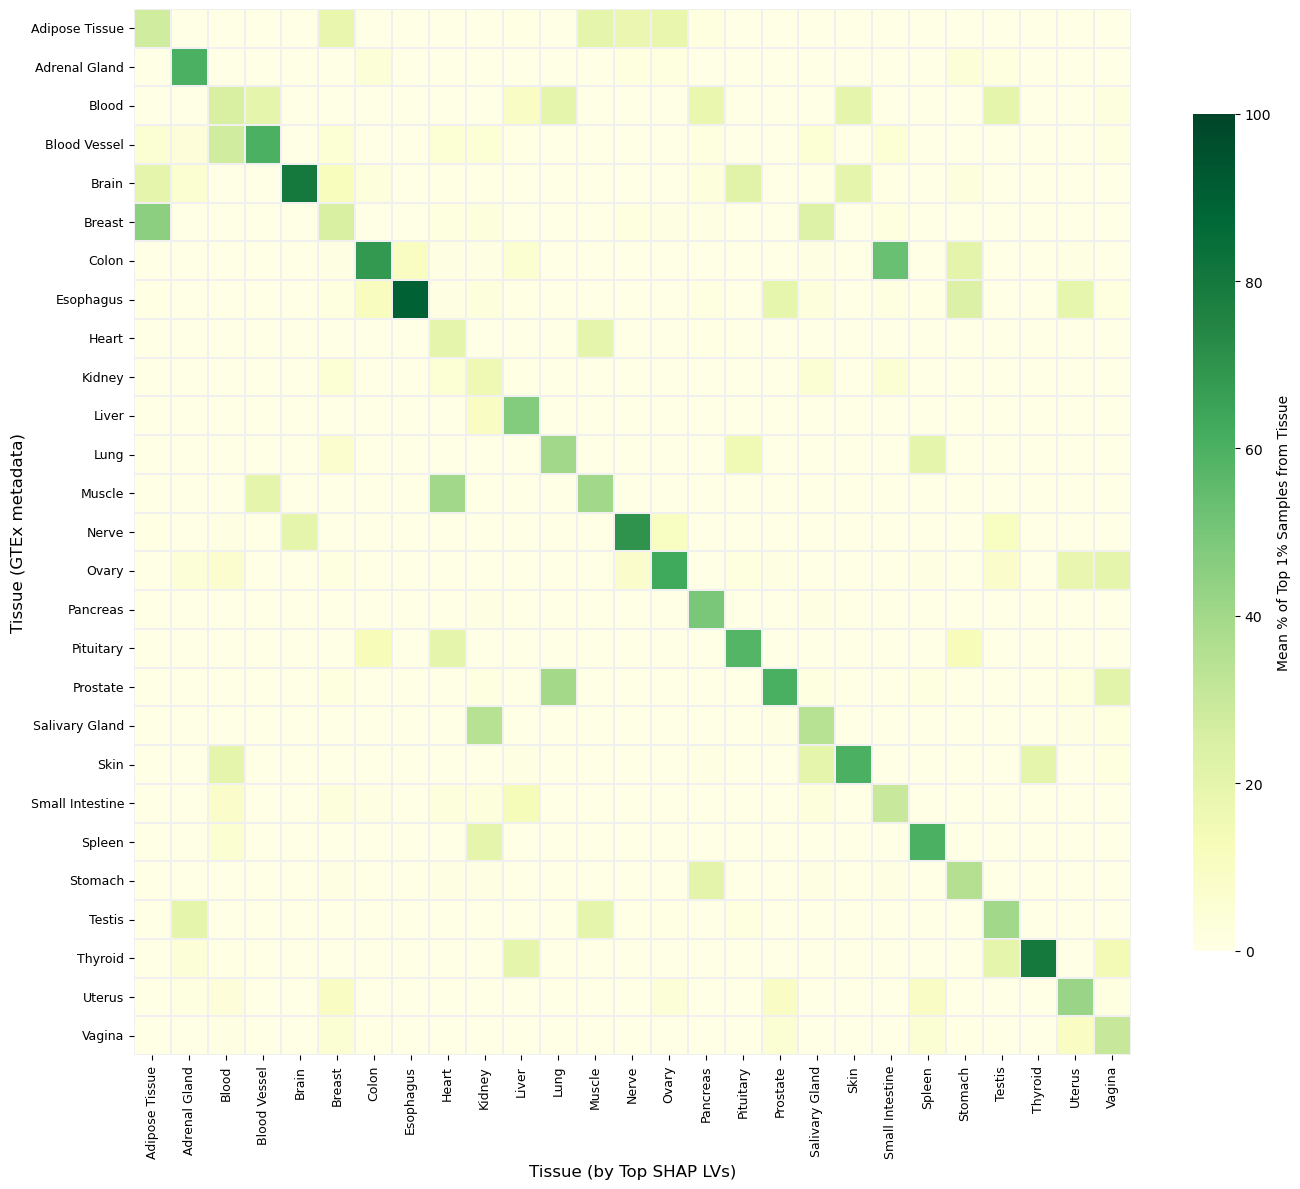


Heatmap: 27 x 27 tissues


In [61]:
# build heatmap matrix: rows=tissues (y-axis), cols=tissues (x-axis)
# each cell = mean percentage across the top 5 LVs for the column tissue
heatmap_matrix = np.zeros((len(tissues_ordered), len(tissues_ordered)))

# store debug info
debug_examples = []

for j, col_tissue in enumerate(tissues_ordered):
    top_lvs = top_per_tissue.get(col_tissue, [])
    
    pcts_per_row = {}
    for i, row_tissue in enumerate(tissues_ordered):
        pcts = [lv_tissue_pct.get(lv, {}).get(row_tissue, 0.0) for lv in top_lvs]
        mean_pct = np.mean(pcts) if pcts else 0.0
        heatmap_matrix[i, j] = mean_pct
        pcts_per_row[row_tissue] = (mean_pct, pcts)
    
    # store debug info for first 3 tissues
    if j < 3:
        sorted_tissues = sorted(pcts_per_row.items(), key=lambda x: x[1][0], reverse=True)[:5]
        debug_examples.append({
            'col_tissue': col_tissue,
            'top_lvs': top_lvs,
            'top_row_tissues': [(t, mean, pcts) for t, (mean, pcts) in sorted_tissues]
        })

# print debug examples
print("=" * 80)
print("DEBUG: Example calculations for first 3 SHAP tissues (columns)")
print("=" * 80)
for ex in debug_examples:
    print(f"\nColumn Tissue: {ex['col_tissue']}")
    print(f"  Top 5 LVs: {ex['top_lvs']}")
    print(f"  Top row tissues (by mean %):")
    for row_tissue, mean_pct, individual_pcts in ex['top_row_tissues']:
        print(f"    {row_tissue}: {mean_pct:.1f}% (individual LVs: {[f'{p:.1f}' for p in individual_pcts]})")

heatmap_df = pd.DataFrame(heatmap_matrix, index=tissues_ordered, columns=tissues_ordered)

# plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    heatmap_df,
    cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    cbar_kws={'label': 'Mean % of Top 1% Samples from Tissue', 'shrink': 0.8}
)

ax.set_xlabel('Tissue (by Top SHAP LVs)', fontsize=12)
ax.set_ylabel('Tissue (GTEx metadata)', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nHeatmap: {len(tissues_ordered)} x {len(tissues_ordered)} tissues")

Original X-axis tissues: 27
Intersection tissues (present in both): 26
DEBUG: Intersection calculations for first 3 tissues

Tissue: Adipose Tissue
  Total significant pathways: 36
  Top pathway tissues (count):
    Breast: 10 (27.8%)
    Adipose Tissue: 10 (27.8%)
    Salivary Gland: 8 (22.2%)
    Brain: 8 (22.2%)

Tissue: Adrenal Gland
  Total significant pathways: 14
  Top pathway tissues (count):
    Adrenal Gland: 12 (85.7%)
    Testis: 1 (7.1%)
    Brain: 1 (7.1%)

Tissue: Blood
  Total significant pathways: 28
  Top pathway tissues (count):
    Artery: 10 (35.7%)
    Cells: 7 (25.0%)
    Blood: 6 (21.4%)
    Small Intestine: 5 (17.9%)


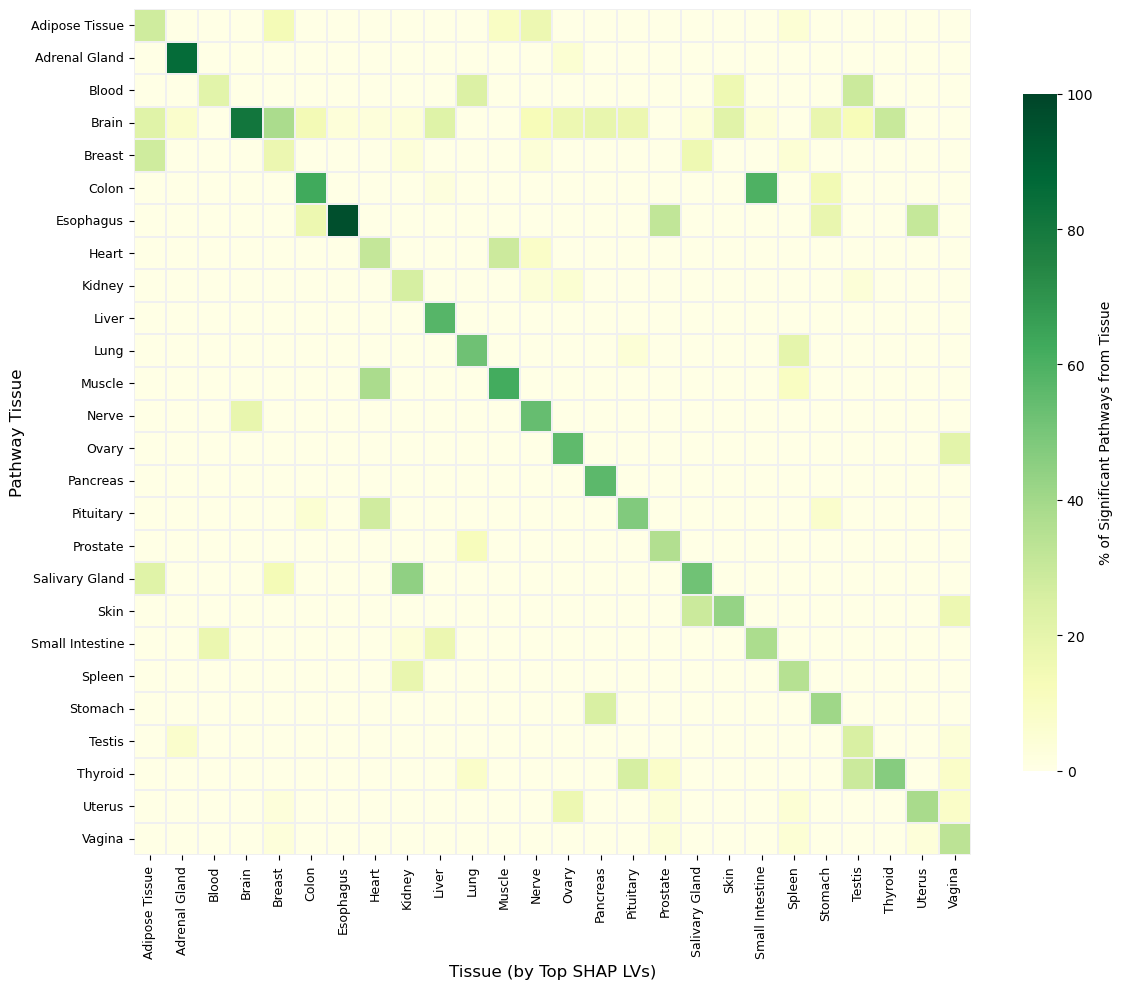

In [62]:
# clean pathway names to keep only the primary tissue type
gtex_GTEx_Tissues_summary['pathway_clean'] = (
    gtex_GTEx_Tissues_summary['pathway']
    .str.split(' - ').str[0]
    .str.split(' Female| Male').str[0]
    .str.strip()
)

# unify naming conventions based on your debug feedback
# 'Artery': 'Blood Vessel' is excluded as per your request
tissue_mapping = {
    'Adipose': 'Adipose Tissue',
    'Whole Blood': 'Blood',
    'Minor Salivary Gland': 'Salivary Gland'
}
gtex_GTEx_Tissues_summary['pathway_clean'] = gtex_GTEx_Tissues_summary['pathway_clean'].replace(tissue_mapping)

# filter pathways using auc and fdr thresholds
filtered_summary = gtex_GTEx_Tissues_summary[
    (gtex_GTEx_Tissues_summary['AUC'] > 0.7) & 
    (gtex_GTEx_Tissues_summary['FDR'] < 0.05)
]

# identify the intersection: keep only tissues found in both datasets
pathway_tissues_in_data = set(filtered_summary['pathway_clean'].unique())
# preserve the original order from tissues_ordered for the intersection
common_tissues = [t for t in tissues_ordered if t in pathway_tissues_in_data]

print(f"Original X-axis tissues: {len(tissues_ordered)}")
print(f"Intersection tissues (present in both): {len(common_tissues)}")

# build heatmap matrix: rows and columns are now identical (common_tissues)
heatmap_matrix = np.zeros((len(common_tissues), len(common_tissues)))

# store debug info
debug_examples = []

for j, tissue_name in enumerate(common_tissues):
    # get lvs for this tissue from the shap list
    top_lvs = top_per_tissue.get(tissue_name, [])
    tissue_pathways = filtered_summary[filtered_summary['LV'].isin(top_lvs)]
    
    if len(tissue_pathways) > 0:
        pathway_counts = tissue_pathways['pathway_clean'].value_counts()
        total = pathway_counts.sum()
        
        for i, row_tissue in enumerate(common_tissues):
            count = pathway_counts.get(row_tissue, 0)
            heatmap_matrix[i, j] = (count / total) * 100
        
        # store debug info for first 3 tissues in the intersection
        if j < 3:
            debug_examples.append({
                'shap_tissue': tissue_name,
                'total_pathways': total,
                'top_pathway_tissues': pathway_counts.head(5).to_dict()
            })

# print debug examples
print("=" * 80)
print("DEBUG: Intersection calculations for first 3 tissues")
print("=" * 80)
for ex in debug_examples:
    print(f"\nTissue: {ex['shap_tissue']}")
    print(f"  Total significant pathways: {ex['total_pathways']}")
    print(f"  Top pathway tissues (count):")
    for pt, count in ex['top_pathway_tissues'].items():
        pct = (count / ex['total_pathways']) * 100
        print(f"    {pt}: {count} ({pct:.1f}%)")

# create dataframe with synchronized labels
heatmap_df = pd.DataFrame(heatmap_matrix, index=common_tissues, columns=common_tissues)

# plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heatmap_df,
    cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    cbar_kws={'label': '% of Significant Pathways from Tissue', 'shrink': 0.8}
)

ax.set_xlabel('Tissue (by Top SHAP LVs)', fontsize=12)
ax.set_ylabel('Pathway Tissue', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [94]:
phenoplier_filtered = (
    phenoplier.loc[phenoplier["fdr"] < 0.05, ["phenotype_desc", "lv", "fdr"]]
    .sort_values("fdr")
    .drop(columns=["fdr"])
    .rename(columns={"phenotype_desc": "phenotype", "lv": "LV"})
)

display(phenoplier_filtered.head())
phenoplier_filtered.shape

,phenotype,LV
278512,Reticulocyte percentage,LV52
637364,Monocyte percentage,LV250
1402860,Reticulocyte count,LV52
1014344,"Non-cancer illness code, self-reported: malabs...",LV324
1475372,Immature reticulocyte fraction,LV52


(2797, 2)

In [95]:
unique_list = []
for tissue, lvs in top_per_tissue.items():
    for lv in lvs:
        if lv not in unique_list:
            match = phenoplier_filtered[phenoplier_filtered['LV'] == lv]['phenotype'].values
            if len(match) > 0:
                unique_list.append(lv)
                trait = match[0]
                print(f"{tissue}: {lv} - {trait}")

Adipose Tissue: LV301 - Comparative body size at age 10
Adipose Tissue: LV263 - Sum of road length of major roads within 100m
Adipose Tissue: LV57 - Treatment/medication code: buprenorphine (20003_1140871732)
Adipose Tissue: LV230 - Type of fat/oil used in cooking: Vegetable oil
Adipose Tissue: LV31 - Diagnoses - main ICD10: G40 Epilepsy
Adrenal Gland: LV20 - Illnesses of mother: Alzheimer's disease/dementia
Adrenal Gland: LV241 - Coffee type: Ground coffee (include espresso, filter etc)
Adrenal Gland: LV365 - Heel bone mineral density (BMD) T-score, automated (left)
Adrenal Gland: LV69 - Xanthelasma of eyelid
Adrenal Gland: LV158 - Treatment/medication code: bendroflumethiazide (20003_1141194794)
Bladder: LV216 - 3mm weak meridian (left)
Bladder: LV152 - Malignant neoplasm of prostate
Bladder: LV338 - Non-cancer illness code, self-reported: tuberculosis (tb)
Bladder: LV40 - Heel bone mineral density (BMD) T-score, automated (left)
Blood: LV186 - Hernia
Blood: LV363 - Basophill percent

In [102]:
gtex_GO_BP_summary_sub = gtex_GO_BP_summary[(gtex_GO_BP_summary['AUC'] > 0.6) & (gtex_GO_BP_summary['FDR'] < 0.1)]

In [103]:
gtex_GO_BP_summary_sub.head()

,pathway,LV,AUC,p_value,FDR,npos,nneg
GO_Biological_Process_20252491,Neurotransmitter Secretion (GO:0007269),LV2,0.953977,0.000041,0.003271,6,21482
GO_Biological_Process_20255133,Synaptic Vesicle Cycle (GO:0099504),LV2,0.906959,0.000068,0.004757,7,21482
GO_Biological_Process_20251335,Homologous Chromosome Pairing at Meiosis (GO:0...,LV6,0.939570,0.003254,0.086386,3,21529
GO_Biological_Process_2025486,Blood Vessel Endothelial Cell Migration (GO:00...,LV9,0.835591,0.003362,0.087795,5,21500
GO_Biological_Process_20255001,Branching Involved in Blood Vessel Morphogenes...,LV9,0.997814,0.005498,0.099817,2,21500


In [104]:
unique_list = []
for tissue, lvs in top_per_tissue.items():
    for lv in lvs:
        if lv not in unique_list:
            match = gtex_GO_BP_summary_sub[gtex_GO_BP_summary_sub['LV'] == lv]['pathway'].values
            if len(match) > 0:
                unique_list.append(lv)
                pathway = match[0]
                print(f"{tissue}: {lv} - {pathway}")

Adrenal Gland: LV365 - C21-steroid Hormone Metabolic Process (GO:0008207)
Blood: LV186 - Embryonic Digestive Tract Development (GO:0048566)
Blood: LV363 - Myeloid Cell Activation Involved in Immune Response (GO:0002275)
Blood: LV264 - B Cell Proliferation (GO:0042100)
Blood Vessel: LV232 - Cardiac Ventricle Development (GO:0003231)
Blood Vessel: LV137 - Sarcomere Organization (GO:0045214)
Brain: LV190 - Neurotransmitter Secretion (GO:0007269)
Colon: LV18 - Glial Cell-Derived Neurotrophic Factor Receptor Signaling Pathway (GO:0035860)
Heart: LV123 - Heart Contraction (GO:0060047)
Kidney: LV50 - Non-Proteinogenic Amino Acid Metabolic Process (GO:0170041)
Liver: LV21 - Alpha-Amino Acid Catabolic Process (GO:1901606)
Liver: LV213 - Reverse Cholesterol Transport (GO:0043691)
Muscle: LV17 - Aerobic Electron Transport Chain (GO:0019646)
Nerve: LV83 - Glial Cell Differentiation (GO:0010001)
Nerve: LV84 - Hormone Biosynthetic Process (GO:0042446)
Pituitary: LV51 - Axonemal Dynein Complex Assemb

## Tissue-aligned traits to keep (by LLM)

- **Adipose tissue**
  - **LV301**: Comparative body size at age 10 (indirect adiposity-related)

- **Adrenal gland**
  - **LV365**: Heel bone mineral density (BMD) T-score (endocrine to bone, indirect)
  - **LV69**: Xanthelasma of eyelid (lipid axis, indirect)
  - **LV158**: Treatment/medication code: bendroflumethiazide (BP axis, indirect)

- **Bladder**
  - None

- **Blood**
  - **LV363**: Basophill percentage (direct blood composition)
  - **LV264**: Monocyte percentage (direct blood composition)

- **Blood vessel**
  - None

- **Brain**
  - **LV190**: Number of incorrect matches in round (cognitive trait)

- **Breast**
  - None

- **Cervix uteri**
  - None

- **Colon**
  - **LV18**: Number of cigarettes previously smoked daily (indirect GI exposure)
  - **LV155**: Number of cigarettes previously smoked daily (same trait)

- **Esophagus**
  - None

- **Fallopian tube**
  - None

- **Heart**
  - **LV123**: Pulse rate, automated reading (direct)
  - **LV349**: Ischaemic heart disease, wide definition (direct)

- **Kidney**
  - **LV50**: Non-cancer illness code, self-reported: gout (urate handling, strong indirect)

- **Liver**
  - **LV21**: Non-cancer illness code, self-reported: high cholesterol (direct metabolic axis)
  - **LV213**: Non-cancer illness code, self-reported: high cholesterol (same trait)

- **Lung**
  - None

- **Muscle**
  - None

- **Nerve**
  - None

- **Ovary**
  - None

- **Pancreas**
  - **LV117**: Age diabetes diagnosed (direct)
  - **LV225**: Diagnoses - main ICD10: C25 Malignant neoplasm of pancreas (direct)

- **Pituitary**
  - None

- **Prostate**
  - None

- **Salivary gland**
  - None

- **Skin**
  - **LV299**: Hair/balding pattern: Pattern 4 (androgen biology, indirect but plausible)

- **Small intestine**
  - None

- **Spleen**
  - None

- **Stomach**
  - None

- **Testis**
  - None

- **Thyroid**
  - None

- **Vagina**
  - None

In [65]:
data = [
    ('Adipose Tissue', 'Trunk fat mass'),
    ('Adipose Tissue', 'Trunk fat percentage'),
    ('Adipose Tissue', 'Whole body fat mass'),
    ('Muscle', 'Hand grip strength (left)'),
    ('Muscle', 'Hand grip strength (right)'),
    ('Muscle', 'Diagnoses - main ICD10: S56 Injury of muscle and tendon at forearm level'),
    ('Blood Vessel', 'Diagnoses - main ICD10: I80 Phlebitis and thrombophlebitis'),
    ('Blood Vessel', 'Peripheral artery disease'),
    ('Blood Vessel', 'Aortic aneurysm'),
    ('Heart', 'Diagnoses - main ICD10: I48 Atrial fibrillation and flutter'),
    ('Heart', 'QRS duration'),
    ('Heart', 'Diagnoses - main ICD10: I20 Angina pectoris'),
    ('Uterus', 'Diagnoses - main ICD10: N92 Excessive, frequent and irregular menstruation'),
    ('Uterus', 'Diagnoses - main ICD10: O20 Haemorrhage in early pregnancy'),
    ('Uterus', 'Diagnoses - main ICD10: N87 Dysplasia of cervix uteri'),
    ('Vagina', 'Diagnoses - main ICD10: N81 Female genital prolapse'),
    ('Vagina', 'Diagnoses - main ICD10: A63 Other predominantly sexually transmitted diseases, not elsewhere classified'),
    ('Breast', 'Diagnoses - main ICD10: C50 Malignant neoplasm of breast'),
    ('Breast', 'Malignant neoplasm of breast'),
    ('Breast', 'Illnesses of mother: Breast cancer'),
    ('Skin', 'Diagnoses - main ICD10: L40 Psoriasis'),
    ('Skin', 'Diagnoses - main ICD10: D22 Melanocytic naevi'),
    ('Skin', 'Diagnoses - main ICD10: L28 Lichen simplex chronicus and prurigo'),
    ('Salivary Gland', 'Mouth/teeth dental problems: Mouth ulcers'),
    ('Brain', 'Diagnoses - main ICD10: G35 Multiple sclerosis'),
    ('Brain', 'Alzheimer’s disease'),
    ('Brain', 'Malignant neoplasm of brain'),
    ('Adrenal Gland', "Non-cancer illness code, self-reported: adrenocortical insufficiency/addison's disease"),
    ('Adrenal Gland', 'Treatment/medication code: fludrocortisone (20003_1140884672)'),
    ('Thyroid', 'Diagnoses - main ICD10: E05 Thyrotoxicosis [hyperthyroidism]'),
    ('Thyroid', 'Non-cancer illness code, self-reported: hypothyroidism/myxoedema'),
    ('Thyroid', 'Diagnoses - main ICD10: D34 Benign neoplasm of thyroid gland'),
    ('Lung', 'Forced expiratory volume in 1-second (FEV1)'),
    ('Lung', 'Forced vital capacity (FVC)'),
    ('Lung', 'Peak expiratory flow (PEF)'),
    ('Spleen', "Diagnoses - main ICD10: C82 Follicular [nodular] non-Hodgkin's lymphoma"),
    ('Spleen', 'Lymphoid leukaemia'),
    ('Spleen', 'Other and unspecified diseases of blood and blood-forming organs'),
    ('Pancreas', 'Diagnoses - main ICD10: E10 Insulin-dependent diabetes mellitus'),
    ('Pancreas', 'Diagnoses - main ICD10: K85 Acute pancreatitis'),
    ('Pancreas', 'Diagnoses - main ICD10: C25 Malignant neoplasm of pancreas'),
    ('Esophagus', 'Non-cancer illness code, self-reported: oesophagitis/barretts oesophagus'),
    ('Stomach', 'Underlying (primary) cause of death: ICD10: C16.9 Stomach, unspecified'),
    ('Stomach', 'Non-cancer illness code, self-reported: gastric/stomach ulcers'),
    ('Stomach', 'Diagnoses - main ICD10: K30 Dyspepsia'),
    ('Colon', 'Diagnoses - main ICD10: K51 Ulcerative colitis'),
    ('Colon', 'Non-cancer illness code, self-reported: diverticular disease/diverticulitis'),
    ('Colon', 'Diagnoses - main ICD10: D12 Benign neoplasm of colon, rectum, anus and anal canal'),
    ('Small Intestine', 'Diagnoses - main ICD10: K90 Intestinal malabsorption'),
    ('Small Intestine', 'Non-cancer illness code, self-reported: crohns disease'),
    ('Small Intestine', 'Type of special diet followed: Gluten-free'),
    ('Prostate', 'Diagnoses - main ICD10: N40 Hyperplasia of prostate'),
    ('Prostate', 'Diagnoses - main ICD10: C61 Malignant neoplasm of prostate'),
    ('Testis', 'C_MALE_GENITAL'),
    ('Testis', 'malignant neoplasm of male genital organs'),
    ('Nerve', 'Carpal tunnel syndrome'),
    ('Nerve', 'Nerve, nerve root and plexus disorders'),
    ('Nerve', 'Other and unspecified mononeuropathies of lower limb'),
    ('Blood', 'Reticulocyte count'),
    ('Blood', 'Mean corpuscular haemoglobin concentration'),
    ('Blood', 'White blood cell (leukocyte) count'),
    ('Pituitary', 'Non-cancer illness code, self-reported: pituitary adenoma/tumour'),
    ('Ovary', 'Diagnoses - main ICD10: O34 Maternal care for known or suspected abnormality of pelvic organs'),
    ('Liver', 'Underlying (primary) cause of death: ICD10: C22.1 Intrahepatic bile duct carcinoma'),
    ('Liver', 'Diagnoses - main ICD10: B18 Chronic viral hepatitis'),
    ('Liver', 'Non-cancer illness code, self-reported: jaundice (unknown cause)'),
    ('Kidney', 'Non-cancer illness code, self-reported: renal failure requiring dialysis'),
    ('Kidney', 'Diagnoses - main ICD10: N13 Obstructive and reflux uropathy'),
    ('Kidney', 'Diagnoses - main ICD10: R31 Unspecified haematuria')
]

# Create DataFrame
df = pd.DataFrame(data, columns=['tissue', 'trait'])

# Display first few rows
print(df)

            tissue                                              trait
0   Adipose Tissue                                     Trunk fat mass
1   Adipose Tissue                               Trunk fat percentage
2   Adipose Tissue                                Whole body fat mass
3           Muscle                          Hand grip strength (left)
4           Muscle                         Hand grip strength (right)
..             ...                                                ...
64           Liver  Diagnoses - main ICD10: B18 Chronic viral hepa...
65           Liver  Non-cancer illness code, self-reported: jaundi...
66          Kidney  Non-cancer illness code, self-reported: renal ...
67          Kidney  Diagnoses - main ICD10: N13 Obstructive and re...
68          Kidney  Diagnoses - main ICD10: R31 Unspecified haemat...

[69 rows x 2 columns]


In [ ]:
# Build binary heatmap: does each top SHAP LV have a significant trait association?
# Uses phenoplier_filtered (FDR < 0.05) to check trait-LV pairs

# reuse the same lv ordering from the tissue heatmap
top_per_tissue = (
    shap_results_df
    .groupby('Tissue')['Feature']
    .apply(lambda x: x.head(5).tolist())
    .to_dict()
)

valid_tissues = accuracy_df[accuracy_df['Best_Test_Balanced_Accuracy'] > 0.95]['Tissue'].tolist()
tissues_ordered = sorted(valid_tissues)

lv_order = []
lv_tissue_group = []
for tissue in tissues_ordered:
    for lv in top_per_tissue.get(tissue, []):
        lv_order.append(lv)
        lv_tissue_group.append(tissue)

# create a set of (phenotype, LV) pairs for fast lookup
phenoplier_pairs = set(zip(phenoplier_filtered['phenotype'], phenoplier_filtered['LV']))

# build binary matrix: rows = traits, cols = LVs
traits = df['trait'].tolist()
binary_matrix = np.zeros((len(traits), len(lv_order)), dtype=int)

for i, trait in enumerate(traits):
    for j, lv in enumerate(lv_order):
        if (trait, lv) in phenoplier_pairs:
            binary_matrix[i, j] = 1

trait_heatmap_df = pd.DataFrame(binary_matrix, index=traits, columns=lv_order)

# plot
fig, ax = plt.subplots(figsize=(max(20, len(lv_order) * 0.4), max(12, len(traits) * 0.25)))

sns.heatmap(
    trait_heatmap_df,
    cmap=['#f0f0f0', '#2ca02c'],
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Trait association (FDR < 0.05)', 'shrink': 0.5, 'ticks': [0, 1]}
)

# add tissue group separators on x-axis
pos = 0
for tissue, group in groupby(lv_tissue_group):
    n = len(list(group))
    mid = pos + n / 2
    ax.text(mid, len(traits) + 2, tissue,
            ha='center', va='top', fontsize=9, rotation=90)
    if pos > 0:
        ax.axvline(x=pos, color='black', linewidth=1.2)
    pos += n

# add tissue group separators on y-axis (group traits by tissue)
row_pos = 0
current_tissue = df['tissue'].iloc[0]
for idx, tissue in enumerate(df['tissue']):
    if tissue != current_tissue:
        ax.axhline(y=idx, color='black', linewidth=1.0)
        current_tissue = tissue

ax.set_xlabel('Top SHAP LVs (grouped by distinguishing tissue)', labelpad=110, fontsize=12)
ax.set_ylabel('Traits (grouped by tissue)', fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# summary
n_associations = binary_matrix.sum()
print(f"Total trait-LV associations found: {n_associations} out of {binary_matrix.size} possible pairs")